In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def getkb(X,Y):
    k=(np.average(Y*X)-np.average(Y)*np.average(X))/(np.average(X*X)-np.average(X)**2)
    b=np.average(Y)-k*np.average(X)
    sigk=np.sqrt(np.abs((np.average(Y*Y)-np.average(Y)*np.average(Y))/(np.average(X*X)-np.average(X)**2) - k*k))/np.sqrt(X.shape[0])
    sigb=sigk*np.sqrt(np.average(X*X)-np.average(X)**2)
    return np.array([k,b,np.abs(sigk/k),np.abs(sigb/b)])

In [3]:
dt=pd.read_excel("data.xlsx",sheet_name=0)
dt

,U,DPf,DPc,Vf,Vc,FP,FV,Re
0,80,31,38,7.238094,8.013738,0.815789,0.903211,2.465766
1,90,36,44,7.800000,8.623224,0.818182,0.904534,2.653300
2,100,44,52,8.623224,9.374433,0.846154,0.919866,2.884441
3,110,48,60,9.006664,10.069757,0.800000,0.894427,3.098387
4,120,50,68,9.192388,10.720075,0.735294,0.857493,3.298485
5,130,49,77,9.100000,11.407454,0.636364,0.797724,3.509986
6,140,49,85,9.100000,11.985408,0.576471,0.759257,3.687818
7,150,52,93,9.374433,12.536746,0.559140,0.747757,3.857460
8,160,55,102,9.641058,13.129356,0.539216,0.734313,4.039802
9,180,63,117,10.318430,14.061650,0.538462,0.733799,4.326662


In [4]:
dt1=pd.read_excel("data.xlsx",sheet_name=1)
dt1

,y,DP,V,VVc
0,0.25,3,2.251666,0.240192
1,0.50,10,4.110961,0.438529
2,0.75,18,5.515433,0.588348
3,1.00,26,6.628725,0.707107
4,1.25,30,7.120393,0.759555
5,1.50,38,8.013738,0.854850
6,2.00,46,8.817029,0.940540
7,2.50,49,9.100000,0.970725
8,3.25,50,9.192388,0.980581
9,4.00,50,9.192388,0.980581


In [5]:
dt2=pd.read_excel("data.xlsx",sheet_name=2)
dt2

,y,DP,V,VVc
0,0.25,15,5.034878,0.316228
1,0.50,40,8.221922,0.516398
2,0.75,53,9.464143,0.594418
3,1.00,62,10.236210,0.642910
4,1.25,69,10.798611,0.678233
5,1.50,73,11.107205,0.697615
6,2.00,80,11.627553,0.730297
7,2.50,86,12.055704,0.757188
8,3.25,95,12.670833,0.795822
9,4.00,102,13.129356,0.824621


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


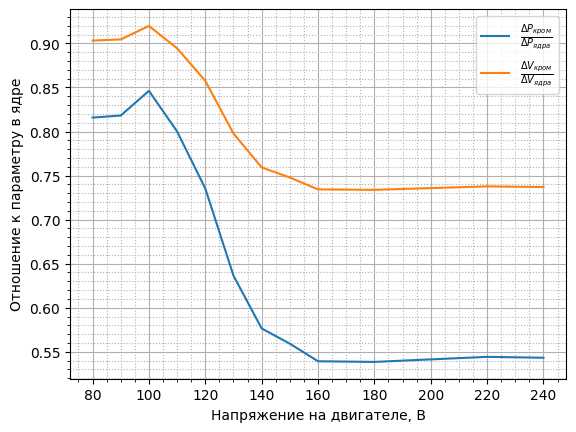

In [6]:
fig,ax=plt.subplots()

ax.plot(dt.U,dt.FP, label=r"$\frac{\Delta P_{кром}}{\Delta P_{ядра}}$")
ax.plot(dt.U,dt.FV, label=r"$\frac{\Delta V_{кром}}{\Delta V_{ядра}}$")

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', linestyle=':')
ax.set_ylabel(r"Отношение к параметру в ядре")
ax.set_xlabel(r"Напряжение на двигателе, В")
ax.legend()

fig.savefig("FlowPar_V.eps")
fig.savefig("FlowPar_V.png")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


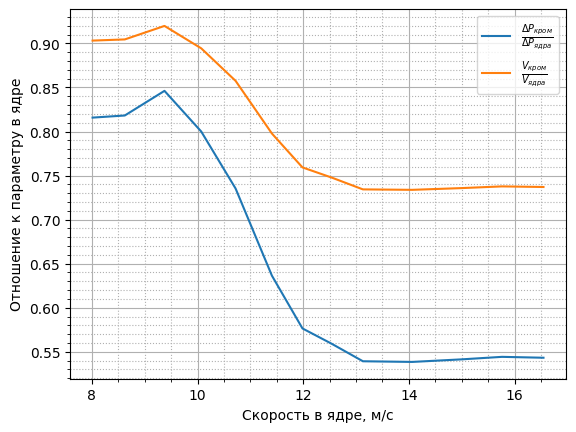

In [7]:
fig,ax=plt.subplots()

ax.plot(dt.Vc,dt.FP, label=r"$\frac{\Delta P_{кром}}{\Delta P_{ядра}}$")
ax.plot(dt.Vc,dt.FV, label=r"$\frac{V_{кром}}{V_{ядра}}$")

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', linestyle=':')
ax.set_ylabel(r"Отношение к параметру в ядре")
ax.set_xlabel(r"Скорость в ядре, м/с")
ax.legend()

fig.savefig("FlowPar_U.eps")
fig.savefig("FlowPar_U.png")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


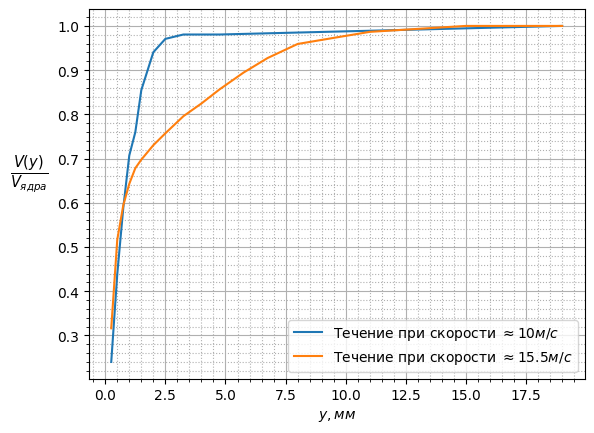

In [8]:
fig,ax=plt.subplots()

ax.plot(np.append(dt1.y,[19]),np.append(dt1.VVc,[1]), label=r"Течение при скорости $\approx 10 м/с$")
ax.plot(dt2.y,dt2.VVc, label=r"Течение при скорости $\approx 15.5 м/с$")

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', linestyle=':')
ax.set_ylabel(r"$\frac{V(y)}{V_{ядра}}$", rotation=0, fontsize=15, labelpad=20)
ax.set_xlabel(r"$y, мм$")
ax.legend()

fig.savefig("VfV.eps")
fig.savefig("VfV.png")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


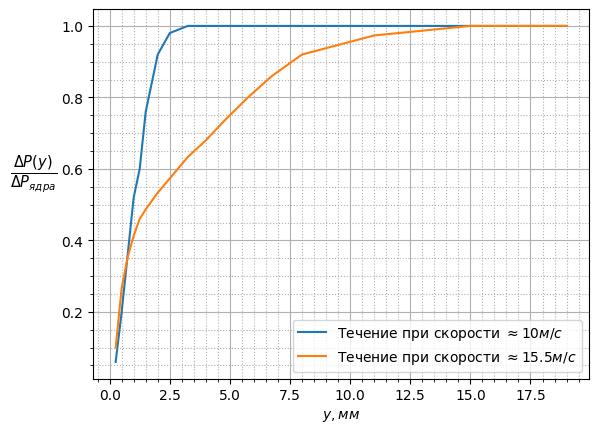

In [9]:
fig,ax=plt.subplots()

ax.plot(np.append(dt1.y,[19]),np.append(dt1.DP/np.max(dt1.DP),[1]), label=r"Течение при скорости $\approx 10 м/с$")
ax.plot(dt2.y,dt2.DP/np.max(dt2.DP), label=r"Течение при скорости $\approx 15.5 м/с$")

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', linestyle=':')
ax.set_ylabel(r"$\frac{\Delta P(y)}{\Delta P_{ядра}}$", rotation=0, fontsize=15, labelpad=20)
ax.set_xlabel(r"$y, мм$")
ax.legend()

fig.savefig("PfP.eps")
fig.savefig("PfP.png")

In [16]:
np.sum(((1-dt1.VVc)[:-1]*(np.array(dt1.y[1:])-np.array(dt1.y[:-1]))))

0.7199570621537228

In [17]:
np.sum(((1-dt2.VVc)[:-1]*(np.array(dt2.y[1:])-np.array(dt2.y[:-1]))))

1.7978190500427222